# gp14 / L800 — group sampling convergence

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})

In [3]:
DATA_ROOT = Path("/cosma/home/durham/dc-hick2/galform_analysis/data/convergence/group_sampling_jobs_by_nvol/gp14")

IZ_LIST = [176, 207, 271]
IZ_TO_Z = {176: 1.007, 207: 0.496, 271: 0.000}
N_LIST  = [600, 700, 800, 900, 1024]
SIM     = "L800"

# Metadata for labeling plots.
MHALO_MIN = 1e11
CENTRALS_ONLY = False
SAMPLE_LABEL = "centrals only" if CENTRALS_ONLY else "centrals + satellites"

frames = []
for n in N_LIST:
    for mode in ["normal", "weighted"]:
        for iz in IZ_LIST:
            fpath = DATA_ROOT / f"n{n}" / mode / SIM / f"group_sampling_convergence_{mode}_{SIM}_iz{iz}.csv"
            if fpath.exists():
                frames.append(pd.read_csv(fpath))

df = pd.concat(frames, ignore_index=True)
df.groupby(['mode', 'iz', 'n_subvol'])['ngal'].first()

mode      iz   n_subvol
normal    176  600         2864904
               700         3336002
               800         3807976
               900         4270066
               1024        4835692
          207  600         3333612
               700         3875675
               800         4418203
               900         4950657
               1024        5603704
          271  600         3763325
               700         4375251
               800         4988307
               900         5590747
               1024        6330772
weighted  176  600         2864904
               700         3336002
               800         3807976
               900         4270066
               1024        4835692
          207  600         3333612
               700         3875675
               800         4418203
               900         4950657
               1024        5603704
          271  600         3763325
               700         4375251
               800         4988

In [ ]:
import contextlib
import io
import time

LOW_N_LIST = [1, 2, 4, 8, 16]
GALFORM_BASE = Path('/cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14')
LOW_RBINS = np.logspace(-1, 1.5, 21)
LOW_R = 0.5 * (LOW_RBINS[:-1] + LOW_RBINS[1:])

from galform_analysis.analysis.correlation.group_sampling_correlation import (
    compute_notebook_style_correlations_for_nvolumes,
)

low_rows = []
t0 = time.time()
for iz in IZ_LIST:
    print(f'[low-n] iz{iz}: computing n={LOW_N_LIST}')

    # The underlying functions can print a lot; keep notebook output concise.
    with contextlib.redirect_stdout(io.StringIO()):
        res = compute_notebook_style_correlations_for_nvolumes(
            base_dir=str(GALFORM_BASE),
            iz_num=iz,
            nvolumes_list=LOW_N_LIST,
            rbins=LOW_RBINS,
            boxsize=542.16,
            mstar_min_log10=9.0,
            mhalo_min=MHALO_MIN,
            n_total_subvolumes=1024,
            num_threads=4,
        )

    for n in LOW_N_LIST:
        ngal = int(res[n]['ngal'])
        for mode, key in [('normal', 'xi_standard'), ('weighted', 'xi_corrected')]:
            low_rows.append(
                pd.DataFrame(
                    {
                        'sim': SIM,
                        'iz': iz,
                        'mode': mode,
                        'n_subvol': n,
                        'bin_idx': np.arange(len(LOW_R), dtype=int),
                        'r': LOW_R,
                        'xi': res[n][key],
                        'ngal': ngal,
                    }
                )
            )

low_df = pd.concat(low_rows, ignore_index=True)

mask_replace = (
    df['sim'].eq(SIM)
    & df['iz'].isin(IZ_LIST)
    & df['n_subvol'].isin(LOW_N_LIST)
    & df['mode'].isin(['normal', 'weighted'])
)

# Replace any existing low-n rows with freshly computed values.
df = pd.concat([df.loc[~mask_replace], low_df], ignore_index=True)

# Keep plotting order low->high and keep n=1024 as reference at the end.
N_LIST = sorted(df['n_subvol'].astype(int).unique().tolist())

print(f'[low-n] done in {time.time() - t0:.1f}s')
print('Updated N_LIST:', N_LIST)
print('Sample selection:', SAMPLE_LABEL)
print(f'Halo-mass cut: mhalo > {MHALO_MIN:.2e}')
df.groupby(['mode', 'iz', 'n_subvol'])['ngal'].first()

Computing low-n convergence for iz176 with n=[1, 2, 4, 8, 16]
Computing low-n convergence for iz207 with n=[1, 2, 4, 8, 16]
Computing low-n convergence for iz271 with n=[1, 2, 4, 8, 16]
Updated N_LIST: [1, 2, 4, 8, 16, 600, 700, 800, 900, 1024]


mode      iz   n_subvol
normal    176  1              4917
               2              9873
               4             20302
               8             41078
               16            81287
               600         2864904
               700         3336002
               800         3807976
               900         4270066
               1024        4835692
          207  1              5647
               2             11329
               4             23333
               8             46848
               16            92716
               600         3333612
               700         3875675
               800         4418203
               900         4950657
               1024        5603704
          271  1              6360
               2             12728
               4             26003
               8             52576
               16           104217
               600         3763325
               700         4375251
               800         4988

## xi(r) — normal vs weighted

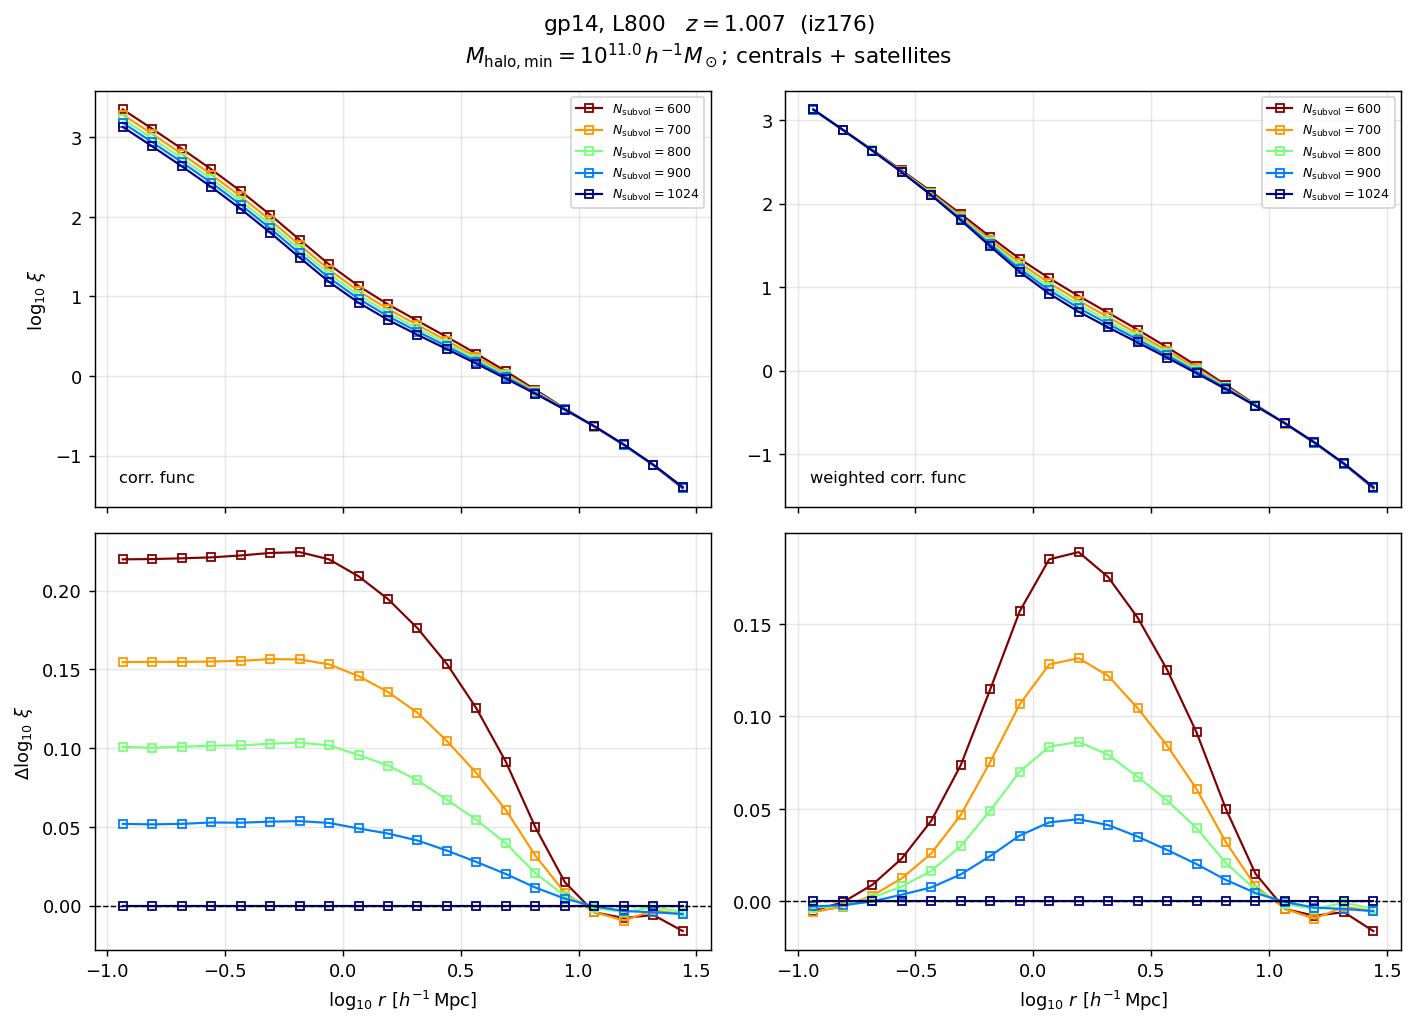

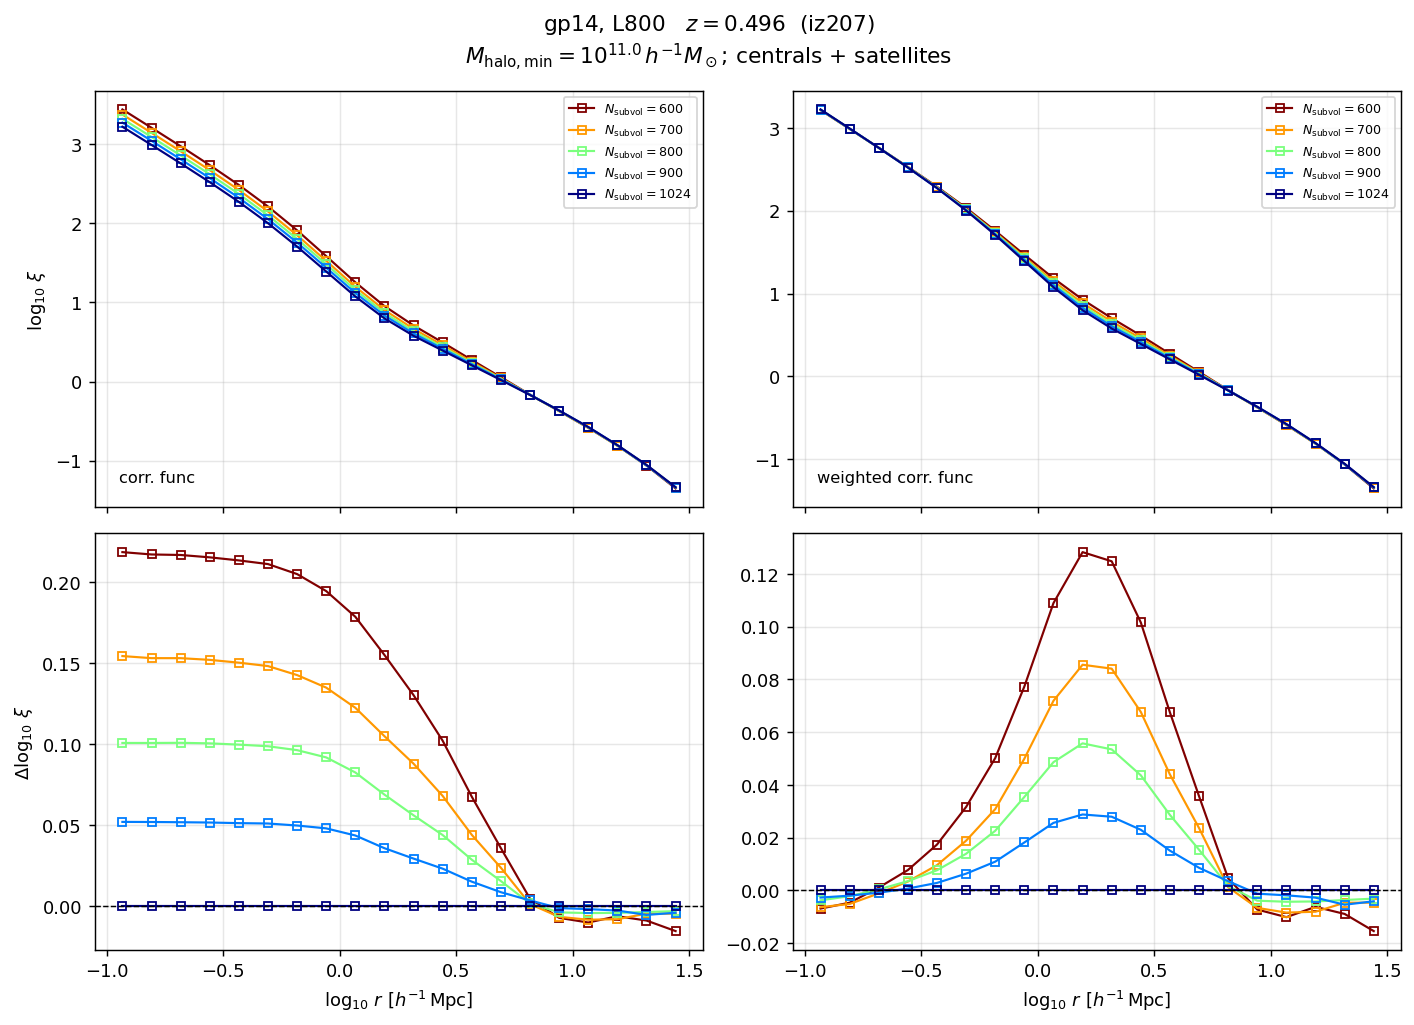

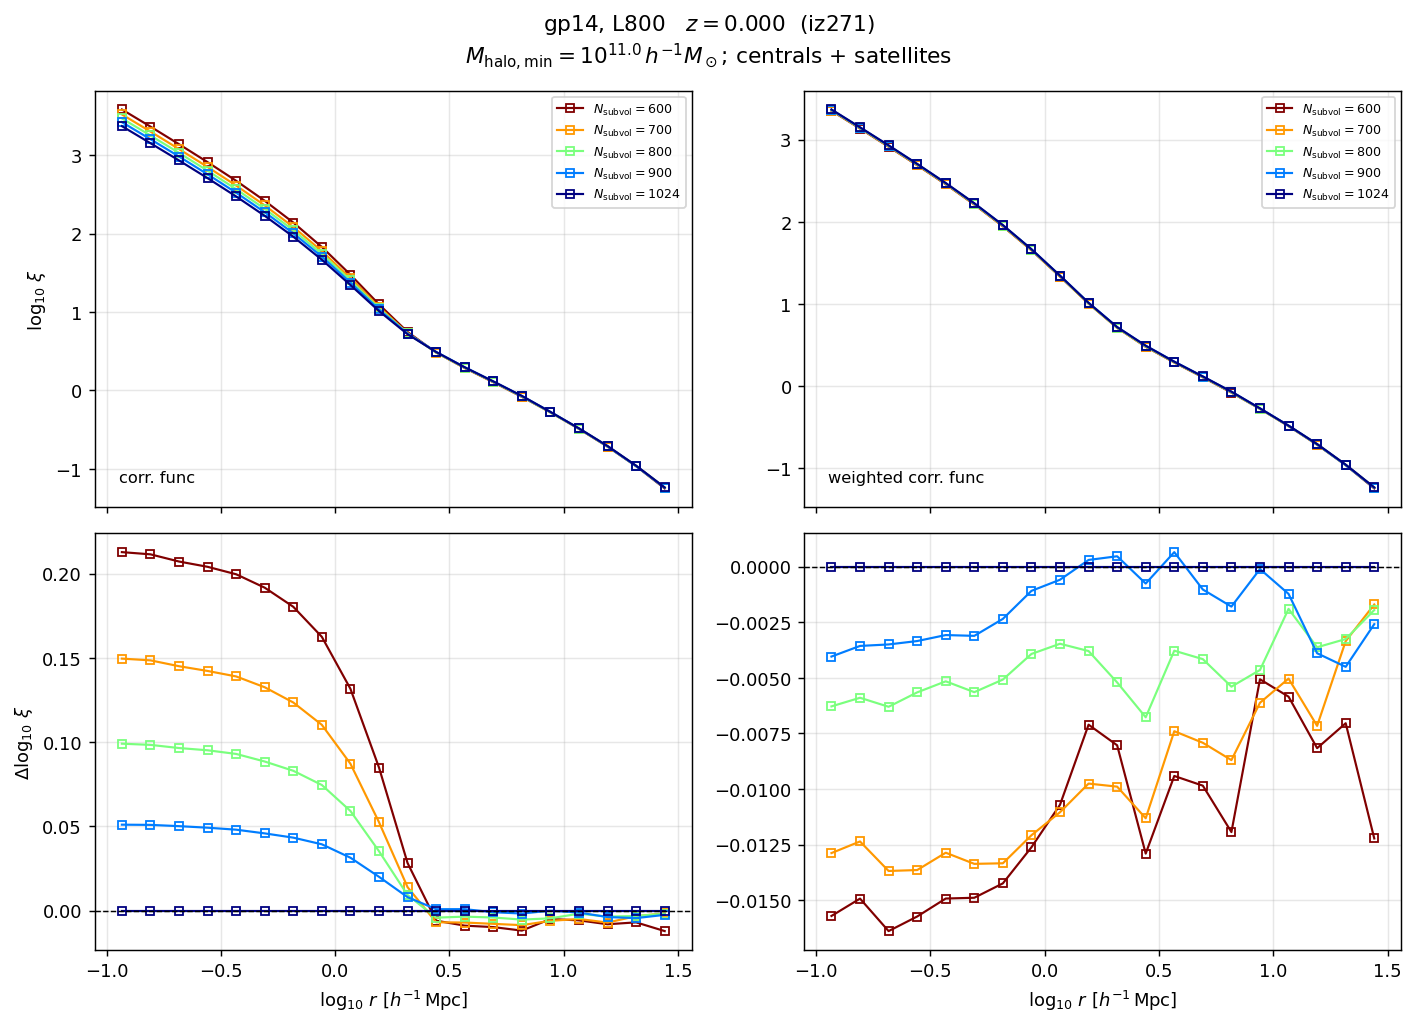

In [4]:
CMAP = cm.jet_r
NORM = Normalize(vmin=0, vmax=len(N_LIST) - 1)

# Fallbacks so the title still works if the metadata cell wasn't rerun.
mhalo_min_plot = globals().get('MHALO_MIN', 1e11)
sample_label_plot = globals().get('SAMPLE_LABEL', 'centrals + satellites')

def plot_convergence(iz):
    z = IZ_TO_Z[iz]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
    (ax_tl, ax_tr), (ax_bl, ax_br) = axes

    ref_n = df[(df['mode'] == 'normal')   & (df['iz'] == iz) & (df['n_subvol'] == N_LIST[-1])].sort_values('r')
    ref_w = df[(df['mode'] == 'weighted') & (df['iz'] == iz) & (df['n_subvol'] == N_LIST[-1])].sort_values('r')

    for i, n in enumerate(N_LIST):
        color = CMAP(NORM(i))
        label = rf'$N_{{\rm subvol}}={n}$'
        mkw = dict(color=color, marker='s', ms=4, lw=1.2, mfc='none', mec=color, label=label)

        sub_n = df[(df['mode'] == 'normal')   & (df['iz'] == iz) & (df['n_subvol'] == n)].sort_values('r')
        sub_w = df[(df['mode'] == 'weighted') & (df['iz'] == iz) & (df['n_subvol'] == n)].sort_values('r')
        logr  = np.log10(sub_n['r'].values)

        ax_tl.plot(logr, np.log10(sub_n['xi'].values),                                   **mkw)
        ax_tr.plot(logr, np.log10(sub_w['xi'].values),                                   **mkw)
        ax_bl.plot(logr, np.log10(sub_n['xi'].values) - np.log10(ref_n['xi'].values),   **mkw)
        ax_br.plot(logr, np.log10(sub_w['xi'].values) - np.log10(ref_w['xi'].values),   **mkw)

    for ax in (ax_bl, ax_br):
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_xlabel(r'$\log_{10}\,r\ [h^{-1}\,\mathrm{Mpc}]$')

    ax_tl.set_ylabel(r'$\log_{10}\,\xi$')
    ax_bl.set_ylabel(r'$\Delta\log_{10}\,\xi$')
    ax_tl.text(0.04, 0.06, 'corr. func',          transform=ax_tl.transAxes, fontsize=9)
    ax_tr.text(0.04, 0.06, 'weighted corr. func', transform=ax_tr.transAxes, fontsize=9)
    ax_tl.legend(loc='upper right', fontsize=7)
    ax_tr.legend(loc='upper right', fontsize=7)

    title_line1 = f'gp14, L800   $z={z:.3f}$  (iz{iz})'
    title_line2 = rf'$M_{{\rm halo,min}}=10^{{{np.log10(mhalo_min_plot):.1f}}}\,h^{{-1}}M_\odot$; {sample_label_plot}'
    fig.suptitle(title_line1 + '\n' + title_line2)
    plt.tight_layout()

for iz in IZ_LIST:
    plot_convergence(iz)

In [25]:
import contextlib
import io

from galform_analysis.analysis.correlation.group_sampling_correlation import (
    compute_notebook_style_correlations_for_nvolumes,
)

MILL_MODELS = ['gp14', 'lc16']
MILL_SIMS = ['Mill1', 'Mill2']
MILL_IZ_BY_SIM = {
    'Mill1': [33, 63],
    'Mill2': [40, 67],
}
MILL_BOXSIZE = {
    'Mill1': 365.0,
    'Mill2': 73.0,
}
MILL_N_LIST = [1, 2, 4, 8, 16]
MILL_TOTAL_SUBVOLS = 64
MILL_RBINS = np.logspace(-1, 1.5, 21)
MILL_R = 0.5 * (MILL_RBINS[:-1] + MILL_RBINS[1:])
GALFORM_OUT_ROOT = Path('/cosma5/data/durham/dc-hick2/Galform_Out')

mhalo_min_plot = globals().get('MHALO_MIN', 1e11)
centrals_only_plot = globals().get('CENTRALS_ONLY', False)
sample_label_plot = 'centrals only' if centrals_only_plot else 'centrals + satellites'

CMAP_MILL = cm.jet_r
NORM_MILL = Normalize(vmin=0, vmax=len(MILL_N_LIST) - 1)


def compute_mill_df(sim, model, iz):
    base_dir = GALFORM_OUT_ROOT / sim / model
    print(f'[{sim} {model} iz{iz}] computing n={MILL_N_LIST}')

    with contextlib.redirect_stdout(io.StringIO()):
        res = compute_notebook_style_correlations_for_nvolumes(
            base_dir=str(base_dir),
            iz_num=iz,
            nvolumes_list=MILL_N_LIST,
            rbins=MILL_RBINS,
            boxsize=MILL_BOXSIZE[sim],
            mstar_min_log10=9.0,
            mhalo_min=mhalo_min_plot,
            centrals_only=centrals_only_plot,
            n_total_subvolumes=MILL_TOTAL_SUBVOLS,
            num_threads=16,
        )

    rows = []
    for n in MILL_N_LIST:
        ngal = int(res[n]['ngal'])
        rows.append(
            pd.DataFrame(
                {
                    'sim': sim,
                    'model': model,
                    'iz': iz,
                    'mode': 'normal',
                    'n_subvol': n,
                    'bin_idx': np.arange(len(MILL_R), dtype=int),
                    'r': MILL_R,
                    'xi': res[n]['xi_standard'],
                    'ngal': ngal,
                }
            )
        )
        rows.append(
            pd.DataFrame(
                {
                    'sim': sim,
                    'model': model,
                    'iz': iz,
                    'mode': 'weighted',
                    'n_subvol': n,
                    'bin_idx': np.arange(len(MILL_R), dtype=int),
                    'r': MILL_R,
                    'xi': res[n]['xi_corrected'],
                    'ngal': ngal,
                }
            )
        )

    return pd.concat(rows, ignore_index=True)


def plot_convergence_from_df(plot_df, sim, model, iz):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
    (ax_tl, ax_tr), (ax_bl, ax_br) = axes

    ref_n = plot_df[(plot_df['mode'] == 'normal') & (plot_df['n_subvol'] == MILL_N_LIST[-1])].sort_values('r')
    ref_w = plot_df[(plot_df['mode'] == 'weighted') & (plot_df['n_subvol'] == MILL_N_LIST[-1])].sort_values('r')

    for i, n in enumerate(MILL_N_LIST):
        color = CMAP_MILL(NORM_MILL(i))
        label = rf'$N_{{\rm subvol}}={n}$'
        mkw = dict(color=color, marker='s', ms=4, lw=1.2, mfc='none', mec=color, label=label)

        sub_n = plot_df[(plot_df['mode'] == 'normal') & (plot_df['n_subvol'] == n)].sort_values('r')
        sub_w = plot_df[(plot_df['mode'] == 'weighted') & (plot_df['n_subvol'] == n)].sort_values('r')

        logr = np.log10(sub_n['r'].values)
        ax_tl.plot(logr, np.log10(sub_n['xi'].values), **mkw)
        ax_tr.plot(logr, np.log10(sub_w['xi'].values), **mkw)
        ax_bl.plot(logr, np.log10(sub_n['xi'].values) - np.log10(ref_n['xi'].values), **mkw)
        ax_br.plot(logr, np.log10(sub_w['xi'].values) - np.log10(ref_w['xi'].values), **mkw)

    for ax in (ax_bl, ax_br):
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_xlabel(r'$\log_{10}\,r\ [h^{-1}\,\mathrm{Mpc}]$')

    ax_tl.set_ylabel(r'$\log_{10}\,\xi$')
    ax_bl.set_ylabel(r'$\Delta\log_{10}\,\xi$')
    ax_tl.text(0.04, 0.06, 'corr. func', transform=ax_tl.transAxes, fontsize=9)
    ax_tr.text(0.04, 0.06, 'weighted corr. func', transform=ax_tr.transAxes, fontsize=9)
    ax_tl.legend(loc='upper right', fontsize=7)
    ax_tr.legend(loc='upper right', fontsize=7)

    title_line1 = rf'{model}, {sim}  (iz{iz})'
    title_line2 = rf'$M_{{\rm halo,min}}=10^{{{np.log10(mhalo_min_plot):.1f}}}\,h^{{-1}}M_\odot$; {sample_label_plot}'
    fig.suptitle(title_line1 + '\n' + title_line2)
    plt.tight_layout()


for sim in MILL_SIMS:
    for model in MILL_MODELS:
        for iz in MILL_IZ_BY_SIM[sim]:
            this_df = compute_mill_df(sim=sim, model=model, iz=iz)
            plot_convergence_from_df(this_df, sim=sim, model=model, iz=iz)

[Mill1 gp14 iz33] computing n=[1, 2, 4, 8, 16]


KeyboardInterrupt: 

## Job-Output Aware Convergence Matrix (Ready While Jobs Run)

These cells are designed to run safely while HPC jobs are still in progress.
They discover available CSV outputs, report missing combinations, and then plot whatever has already landed on disk.

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    fallback = Path('/cosma/home/durham/dc-hick2/galform_analysis')
    return fallback if fallback.exists() else start


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
DATA_ROOT = REPO_ROOT / 'data'

MODEL_NAMES = {'gp14', 'lc16'}

DETERMINISTIC_ROOTS = [
    DATA_ROOT / 'convergence' / 'group_sampling_jobs',
    DATA_ROOT / 'convergence' / 'group_sampling_halo_filter_sets',
]

RANDOM_ROOTS = [
    DATA_ROOT / 'halo_sampling_4_subvol_weighted_random',
    DATA_ROOT / 'halo_sampling_4_subvol_weighted_random_seeded',
]


def _infer_model_from_path(path: Path) -> str:
    lowered_parts = [p.lower() for p in path.parts]
    for model in MODEL_NAMES:
        if model in lowered_parts:
            return model
    return 'legacy'


def _infer_set_tag(path: Path) -> str:
    parts = list(path.parts)
    for i, part in enumerate(parts):
        if part in MODEL_NAMES and i + 1 < len(parts):
            nxt = parts[i + 1]
            if nxt in {'normal', 'weighted'}:
                return 'default'
            return nxt
    for part in parts:
        if part.startswith('n') and part[1:].isdigit():
            return part
    return 'default'


def _drop_legacy_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or 'model' not in df.columns:
        return df

    key_cols = [c for c in ['sim', 'iz', 'mode', 'set_tag', 'n_subvol', 'bin_idx', 'r'] if c in df.columns]
    if not key_cols:
        return df

    nonlegacy_keys = (
        df[df['model'] != 'legacy'][key_cols]
        .drop_duplicates()
        .assign(_has_nonlegacy=1)
    )
    if nonlegacy_keys.empty:
        return df

    merged = df.merge(nonlegacy_keys, on=key_cols, how='left')
    drop_mask = (merged['model'] == 'legacy') & (merged['_has_nonlegacy'] == 1)
    out = merged.loc[~drop_mask].drop(columns=['_has_nonlegacy'])
    return out


def _load_deterministic_csvs() -> pd.DataFrame:
    # Supports both merged outputs (..._izXXX.csv) and single-n shards (..._izXXX_nN.csv).
    re_mode = re.compile(r'group_sampling_convergence_(normal|weighted)_(.+)_iz(\d+)(?:_n(\d+))?\.csv$')
    re_nomode = re.compile(r'group_sampling_convergence_(.+)_iz(\d+)(?:_n(\d+))?\.csv$')

    frames = []
    for root in DETERMINISTIC_ROOTS:
        if not root.exists():
            continue
        for csv_path in root.rglob('group_sampling_convergence_*.csv'):
            m_mode = re_mode.match(csv_path.name)
            m_nomode = re_nomode.match(csv_path.name)
            if not m_mode and not m_nomode:
                continue

            try:
                df = pd.read_csv(csv_path)
            except Exception as exc:
                print(f'Failed reading {csv_path}: {exc}')
                continue

            if df.empty:
                continue

            model = _infer_model_from_path(csv_path)
            set_tag = _infer_set_tag(csv_path)
            source_group = 'group_sampling_halo_filter_sets' if 'group_sampling_halo_filter_sets' in str(csv_path) else 'group_sampling_jobs'

            if m_mode and 'xi' in df.columns:
                mode, sim, iz, n_from_name = m_mode.groups()
                n_from_name = int(n_from_name) if n_from_name is not None else None

                out = df.copy()
                out['mode'] = mode
                out['sim'] = sim
                out['iz'] = int(iz)
                out['model'] = model
                out['set_tag'] = set_tag
                out['source_group'] = source_group
                out['source_file'] = str(csv_path)
                if ('n_subvol' not in out.columns or out['n_subvol'].isna().all()) and n_from_name is not None:
                    out['n_subvol'] = n_from_name

                frames.append(out)
                continue

            if m_nomode and {'xi_standard', 'xi_corrected'}.issubset(df.columns):
                sim, iz, n_from_name = m_nomode.groups()
                n_from_name = int(n_from_name) if n_from_name is not None else None
                base_cols = [c for c in ['n_subvol', 'bin_idx', 'r', 'ngal'] if c in df.columns]

                dfn = df[base_cols + ['xi_standard']].rename(columns={'xi_standard': 'xi'}).copy()
                dfn['mode'] = 'normal'
                dfn['sim'] = sim
                dfn['iz'] = int(iz)
                dfn['model'] = model
                dfn['set_tag'] = set_tag
                dfn['source_group'] = source_group
                dfn['source_file'] = str(csv_path)
                if ('n_subvol' not in dfn.columns or dfn['n_subvol'].isna().all()) and n_from_name is not None:
                    dfn['n_subvol'] = n_from_name

                dfw = df[base_cols + ['xi_corrected']].rename(columns={'xi_corrected': 'xi'}).copy()
                dfw['mode'] = 'weighted'
                dfw['sim'] = sim
                dfw['iz'] = int(iz)
                dfw['model'] = model
                dfw['set_tag'] = set_tag
                dfw['source_group'] = source_group
                dfw['source_file'] = str(csv_path)
                if ('n_subvol' not in dfw.columns or dfw['n_subvol'].isna().all()) and n_from_name is not None:
                    dfw['n_subvol'] = n_from_name

                frames.extend([dfn, dfw])

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    out['iz'] = pd.to_numeric(out['iz'], errors='coerce').astype('Int64')
    out['n_subvol'] = pd.to_numeric(out.get('n_subvol', np.nan), errors='coerce').astype('Int64')
    out['r'] = pd.to_numeric(out.get('r', np.nan), errors='coerce')
    out['xi'] = pd.to_numeric(out.get('xi', np.nan), errors='coerce')
    if 'bin_idx' not in out.columns:
        out['bin_idx'] = out.groupby('source_file').cumcount()
    out['bin_idx'] = pd.to_numeric(out['bin_idx'], errors='coerce').astype('Int64')

    out = _drop_legacy_duplicates(out)
    return out


def _load_random_csvs() -> pd.DataFrame:
    re_mode = re.compile(r'halo_sampling_convergence_(standard|weighted|normal|halo)_(.+)_iz(\d+)\.csv$')

    frames = []
    for root in RANDOM_ROOTS:
        if not root.exists():
            continue

        for csv_path in root.rglob('halo_sampling_convergence_*_iz*.csv'):
            m_mode = re_mode.match(csv_path.name)
            if not m_mode:
                continue

            mode, sim, iz = m_mode.groups()

            try:
                df = pd.read_csv(csv_path)
            except Exception as exc:
                print(f'Failed reading {csv_path}: {exc}')
                continue

            if df.empty:
                continue

            model = _infer_model_from_path(csv_path)
            parts = csv_path.parts

            mhalo_tag = next((p.split('_', 1)[1] for p in parts if p.startswith('mhalo_')), 'unknown')
            centrals = next((int(p.split('_')[-1]) for p in parts if p.startswith('centrals_')), np.nan)
            n_subvol_dir = next((int(p.split('_')[-1]) for p in parts if p.startswith('nsubvol_')), np.nan)

            seed_from_path = np.nan
            for part in parts:
                if part.startswith('seed_'):
                    s = part.split('_', 1)[1]
                    if s.isdigit():
                        seed_from_path = int(s)

            out = df.copy()
            out['mode'] = mode
            out['sim'] = sim
            out['iz'] = int(iz)
            out['model'] = model
            out['mhalo_tag'] = mhalo_tag
            out['centrals_only'] = centrals
            out['source_file'] = str(csv_path)

            if 'n_subvol' not in out.columns:
                out['n_subvol'] = n_subvol_dir
            if 'selection_seed' not in out.columns:
                out['selection_seed'] = seed_from_path

            frames.append(out)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    out['iz'] = pd.to_numeric(out['iz'], errors='coerce').astype('Int64')
    out['n_subvol'] = pd.to_numeric(out.get('n_subvol', np.nan), errors='coerce').astype('Int64')
    out['r'] = pd.to_numeric(out.get('r', np.nan), errors='coerce')
    out['xi'] = pd.to_numeric(out.get('xi', np.nan), errors='coerce')
    out['selection_seed'] = pd.to_numeric(out.get('selection_seed', np.nan), errors='coerce').astype('Int64')
    out['centrals_only'] = pd.to_numeric(out.get('centrals_only', np.nan), errors='coerce').astype('Int64')
    if 'bin_idx' not in out.columns:
        out['bin_idx'] = out.groupby('source_file').cumcount()
    out['bin_idx'] = pd.to_numeric(out['bin_idx'], errors='coerce').astype('Int64')
    return out


det_df = _load_deterministic_csvs()
rand_df = _load_random_csvs()

print(f'Repo root: {REPO_ROOT}')
print(f'Deterministic rows: {len(det_df)}')
print(f'Random-seeded rows: {len(rand_df)}')

if not det_df.empty:
    det_files = det_df[['model', 'sim', 'iz', 'mode', 'set_tag', 'source_file']].drop_duplicates()
    print(f'Deterministic unique files: {len(det_files)}')
    print('Deterministic models discovered:', sorted(det_df['model'].dropna().unique().tolist()))

    expected_rows = []
    l800_sets = ['default', 'mhalo1e9_all', 'mhalo1e9_cen', 'mhalo1e10_all', 'mhalo1e10_cen', 'mhalo1e11_all', 'mhalo1e11_cen']
    for iz in [155, 207, 271]:
        for mode in ['normal', 'weighted']:
            for set_tag in l800_sets:
                expected_rows.append(('lc16', 'L800', iz, mode, set_tag))
    for sim, iz_list in [('Mill1', [33, 63]), ('Mill2', [40, 67])]:
        for iz in iz_list:
            for mode in ['normal', 'weighted']:
                for set_tag in l800_sets:
                    expected_rows.append(('gp14', sim, iz, mode, set_tag))

    expected_det = pd.MultiIndex.from_tuples(expected_rows, names=['model', 'sim', 'iz', 'mode', 'set_tag'])
    present_det = pd.MultiIndex.from_frame(det_files[['model', 'sim', 'iz', 'mode', 'set_tag']])
    missing_det = expected_det.difference(present_det)

    print(f'Deterministic completion: {len(present_det)}/{len(expected_det)} expected file-combos')
    if len(missing_det):
        print('Missing deterministic combos (first 30):')
        display(pd.DataFrame(list(missing_det[:30]), columns=expected_det.names))
    else:
        print('Deterministic matrix complete for expected combinations.')

if not rand_df.empty:
    rand_files = rand_df[['model', 'sim', 'iz', 'mode', 'mhalo_tag', 'centrals_only', 'selection_seed', 'source_file']].drop_duplicates()
    print(f'Random unique files: {len(rand_files)}')
    seeds = sorted(rand_files['selection_seed'].dropna().astype(int).unique().tolist())
    print('Random seeds discovered:', seeds)
    display(rand_files.groupby(['model', 'sim', 'mode', 'mhalo_tag', 'centrals_only', 'selection_seed']).size().to_frame('n_files').reset_index().head(30))

# These are reused by the next plotting cells.
CONVERGENCE_DET_DF = det_df
CONVERGENCE_RAND_DF = rand_df

Repo root: /cosma/home/durham/dc-hick2/galform_analysis
Deterministic rows: 240
Random-seeded rows: 5660
Deterministic unique files: 6
Deterministic models discovered: ['gp14']
Deterministic completion: 6/98 expected file-combos
Missing deterministic combos (first 30):


,model,sim,iz,mode,set_tag
0,gp14,Mill1,33,normal,default
1,gp14,Mill1,33,normal,mhalo1e10_all
2,gp14,Mill1,33,normal,mhalo1e10_cen
3,gp14,Mill1,33,normal,mhalo1e11_all
4,gp14,Mill1,33,normal,mhalo1e11_cen
5,gp14,Mill1,33,normal,mhalo1e9_all
6,gp14,Mill1,33,normal,mhalo1e9_cen
7,gp14,Mill1,33,weighted,default
8,gp14,Mill1,33,weighted,mhalo1e10_all
9,gp14,Mill1,33,weighted,mhalo1e10_cen


Random unique files: 283
Random seeds discovered: [314159]


,model,sim,mode,mhalo_tag,centrals_only,selection_seed,n_files
0,lc16,L800,weighted,1e11,0,314159,48
1,lc16,L800,weighted,1e11,1,314159,48
2,lc16,L800,weighted,1e13,0,314159,48
3,lc16,L800,weighted,1e13,1,314159,48
4,lc16,L800,weighted,1e9,0,314159,44
5,lc16,L800,weighted,1e9,1,314159,47


,model,sim,iz,mode,set_tag,n_subvol,metric,n_points,n_subvol_ref,metric_ref,frac_to_ref,abs_frac_error
0,gp14,L800,176,normal,default,800,27.985748,6,1024,26.985424,1.037069,0.037069
1,gp14,L800,176,normal,default,1024,26.985424,6,1024,26.985424,1.000000,0.000000
2,gp14,L800,176,weighted,default,800,27.985748,6,1024,26.985424,1.037069,0.037069
3,gp14,L800,176,weighted,default,1024,26.985424,6,1024,26.985424,1.000000,0.000000
4,gp14,L800,207,normal,default,800,30.848690,6,1024,30.603730,1.008004,0.008004
5,gp14,L800,207,normal,default,1024,30.603730,6,1024,30.603730,1.000000,0.000000
6,gp14,L800,207,weighted,default,800,30.848686,6,1024,30.603730,1.008004,0.008004
7,gp14,L800,207,weighted,default,1024,30.603730,6,1024,30.603730,1.000000,0.000000
8,gp14,L800,271,normal,default,800,37.626783,6,1024,37.959872,0.991225,0.008775
9,gp14,L800,271,normal,default,1024,37.959872,6,1024,37.959872,1.000000,0.000000


None of the focus panels are available yet. Plotting first 12 available combos instead.


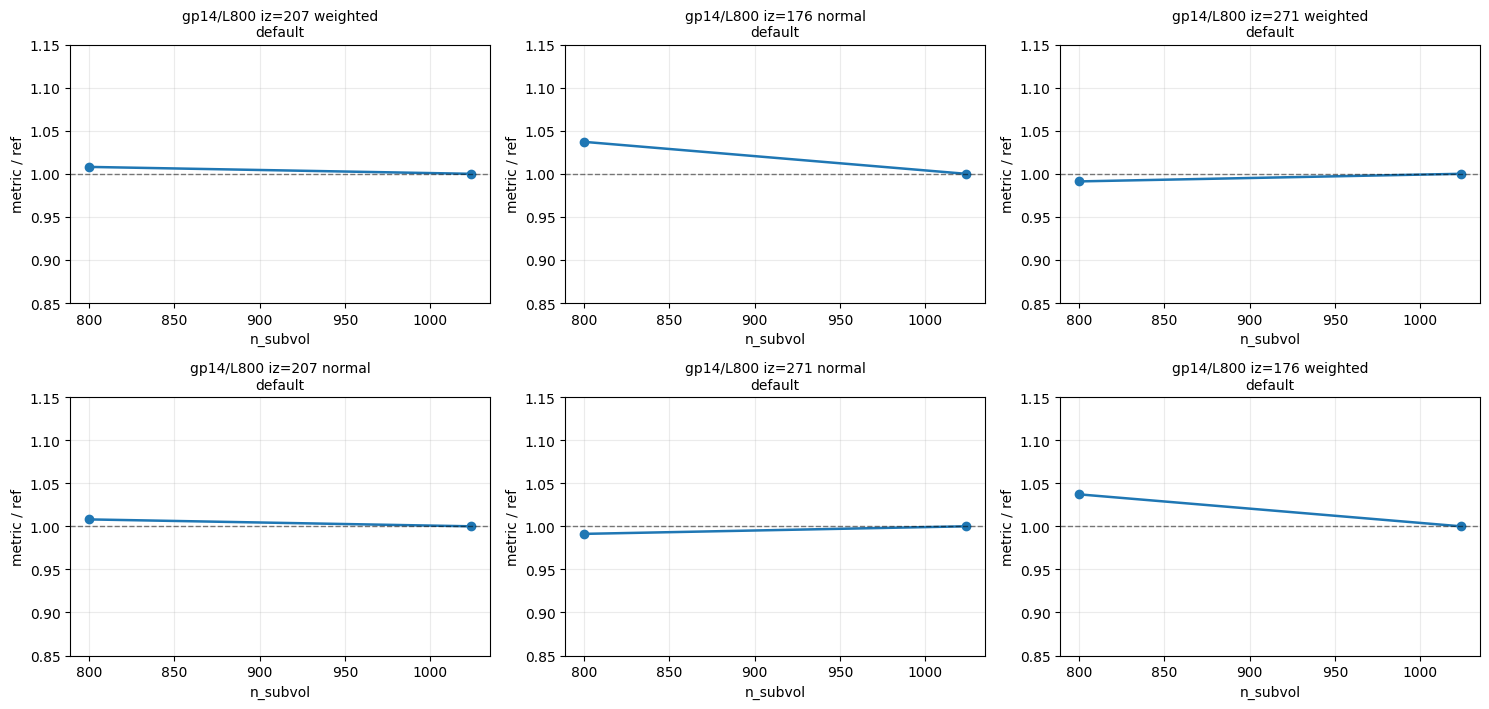

,model,sim,iz,mode,set_tag,n_subvol,abs_frac_error
0,gp14,L800,176,normal,default,800,0.037069
1,gp14,L800,176,normal,default,1024,0.000000
2,gp14,L800,176,weighted,default,800,0.037069
3,gp14,L800,176,weighted,default,1024,0.000000
4,gp14,L800,207,normal,default,800,0.008004
5,gp14,L800,207,normal,default,1024,0.000000
6,gp14,L800,207,weighted,default,800,0.008004
7,gp14,L800,207,weighted,default,1024,0.000000
8,gp14,L800,271,normal,default,800,0.008775
9,gp14,L800,271,normal,default,1024,0.000000


In [5]:
# Deterministic convergence plots (works with partial outputs)

if 'CONVERGENCE_DET_DF' not in globals() or CONVERGENCE_DET_DF.empty:
    print('No deterministic convergence data loaded yet. Run the previous loader cell first.')
else:
    det = CONVERGENCE_DET_DF.copy()

    # Keep only usable rows for plotting.
    det = det.dropna(subset=['r', 'xi', 'n_subvol'])
    if det.empty:
        print('Deterministic dataframe has no plottable rows after dropping NaNs.')
    else:
        rmin, rmax = 3.0, 20.0
        det = det[(det['r'] >= rmin) & (det['r'] <= rmax)]

        if det.empty:
            print(f'No deterministic rows in r-window [{rmin}, {rmax}] Mpc/h.')
        else:
            # Use a scalar summary per n_subvol to make convergence curves easy to compare.
            # Metric: mean of r^2 * xi(r) over mid scales.
            det['metric'] = (det['r'] ** 2) * det['xi']
            metric_df = (
                det.groupby(['model', 'sim', 'iz', 'mode', 'set_tag', 'n_subvol'], as_index=False)
                   .agg(metric=('metric', 'mean'), n_points=('metric', 'size'))
            )

            # Compare each n_subvol value against the largest available n_subvol for that combo.
            ref_df = (
                metric_df.sort_values('n_subvol')
                         .groupby(['model', 'sim', 'iz', 'mode', 'set_tag'], as_index=False)
                         .tail(1)
                         .rename(columns={'n_subvol': 'n_subvol_ref', 'metric': 'metric_ref'})
                         [['model', 'sim', 'iz', 'mode', 'set_tag', 'n_subvol_ref', 'metric_ref']]
            )

            metric_df = metric_df.merge(
                ref_df,
                on=['model', 'sim', 'iz', 'mode', 'set_tag'],
                how='left',
            )
            metric_df['frac_to_ref'] = metric_df['metric'] / metric_df['metric_ref']
            metric_df['abs_frac_error'] = (metric_df['frac_to_ref'] - 1.0).abs()

            display(
                metric_df.sort_values(['model', 'sim', 'iz', 'mode', 'set_tag', 'n_subvol'])
                         .head(20)
            )

            # Focus panel set for immediate science checks.
            focus_panels = [
                ('lc16', 'L800', 271, 'weighted', 'default'),
                ('lc16', 'L800', 271, 'weighted', 'mhalo1e9_all'),
                ('lc16', 'L800', 271, 'weighted', 'mhalo1e9_cen'),
                ('lc16', 'L800', 271, 'weighted', 'mhalo1e11_all'),
                ('lc16', 'L800', 271, 'weighted', 'mhalo1e11_cen'),
                ('gp14', 'Mill1', 63, 'weighted', 'default'),
                ('gp14', 'Mill1', 63, 'weighted', 'mhalo1e9_all'),
                ('gp14', 'Mill1', 63, 'weighted', 'mhalo1e9_cen'),
                ('gp14', 'Mill2', 67, 'weighted', 'default'),
                ('gp14', 'Mill2', 67, 'weighted', 'mhalo1e11_all'),
                ('gp14', 'Mill2', 67, 'weighted', 'mhalo1e11_cen'),
            ]

            available_keys = set(
                metric_df[['model', 'sim', 'iz', 'mode', 'set_tag']]
                .drop_duplicates()
                .itertuples(index=False, name=None)
            )
            panels = [k for k in focus_panels if k in available_keys]

            if not panels:
                print('None of the focus panels are available yet. Plotting first 12 available combos instead.')
                panels = list(available_keys)[:12]

            if not panels:
                print('No deterministic combo panels available yet.')
            else:
                ncols = 3
                nrows = int(np.ceil(len(panels) / ncols))
                fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows), squeeze=False)
                axes = axes.ravel()

                for i, key in enumerate(panels):
                    ax = axes[i]
                    model, sim, iz, mode, set_tag = key
                    sdf = metric_df[
                        (metric_df['model'] == model)
                        & (metric_df['sim'] == sim)
                        & (metric_df['iz'] == iz)
                        & (metric_df['mode'] == mode)
                        & (metric_df['set_tag'] == set_tag)
                    ].sort_values('n_subvol')

                    if sdf.empty:
                        ax.set_visible(False)
                        continue

                    ax.plot(sdf['n_subvol'], sdf['frac_to_ref'], marker='o', lw=1.8)
                    ax.axhline(1.0, ls='--', lw=1.0, color='k', alpha=0.5)
                    ax.set_ylim(0.85, 1.15)
                    ax.grid(alpha=0.25)
                    ax.set_title(f'{model}/{sim} iz={iz} {mode}\n{set_tag}', fontsize=10)
                    ax.set_xlabel('n_subvol')
                    ax.set_ylabel('metric / ref')

                for j in range(len(panels), len(axes)):
                    axes[j].set_visible(False)

                plt.tight_layout()
                plt.show()

            # Table view of convergence quality at each n_subvol.
            conv_table = (
                metric_df.groupby(['model', 'sim', 'iz', 'mode', 'set_tag', 'n_subvol'], as_index=False)
                         .agg(abs_frac_error=('abs_frac_error', 'mean'))
                         .sort_values(['model', 'sim', 'iz', 'mode', 'set_tag', 'n_subvol'])
            )
            display(conv_table.head(40))

Seed spread note: CV=0.0 where only one seed is currently available (interim state while additional seeded runs finish).


,model,sim,iz,mode_norm,mhalo_tag,centrals_only,n_subvol,n_seed,metric_mean,metric_std,seed_cv
0,lc16,L800,155,weighted,1e11,0,2,1,90.005402,NaN,0.0
1,lc16,L800,155,weighted,1e11,0,4,1,114.630179,NaN,0.0
2,lc16,L800,155,weighted,1e11,0,8,1,112.231589,NaN,0.0
3,lc16,L800,155,weighted,1e11,0,10,1,120.125567,NaN,0.0
4,lc16,L800,155,weighted,1e11,0,15,1,113.994816,NaN,0.0
5,lc16,L800,155,weighted,1e11,0,20,1,108.935474,NaN,0.0
6,lc16,L800,155,weighted,1e11,0,25,1,107.893748,NaN,0.0
7,lc16,L800,155,weighted,1e11,0,30,1,107.323801,NaN,0.0
8,lc16,L800,155,weighted,1e11,0,50,1,108.189084,NaN,0.0
9,lc16,L800,155,weighted,1e11,0,100,1,109.806071,NaN,0.0


Random seeded completion: 18/36 expected combo groups
Missing random combo groups (first 30):


,model,sim,iz,mode_norm,mhalo_tag,centrals_only
0,lc16,L800,155,normal,1e11,0
1,lc16,L800,155,normal,1e11,1
2,lc16,L800,155,normal,1e13,0
3,lc16,L800,155,normal,1e13,1
4,lc16,L800,155,normal,1e9,0
5,lc16,L800,155,normal,1e9,1
6,lc16,L800,207,normal,1e11,0
7,lc16,L800,207,normal,1e11,1
8,lc16,L800,207,normal,1e13,0
9,lc16,L800,207,normal,1e13,1


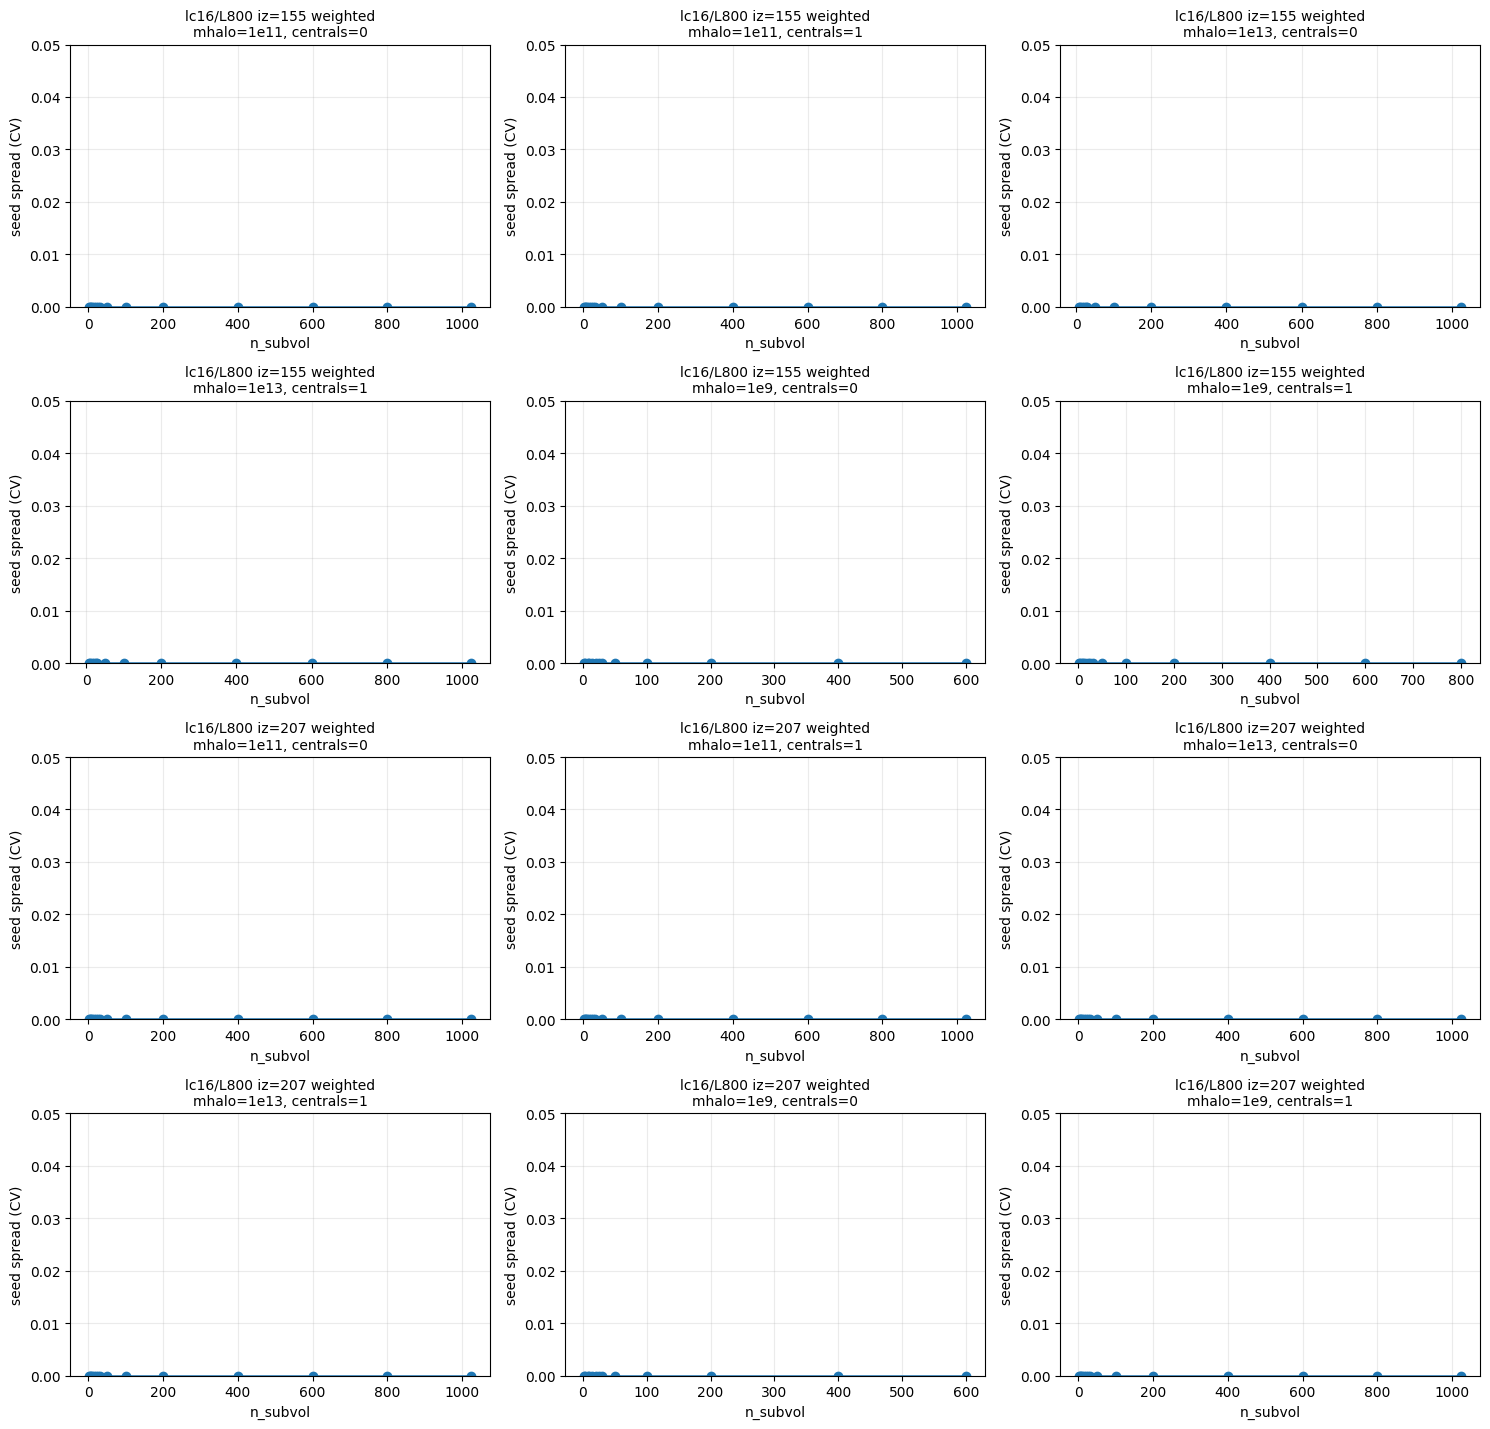

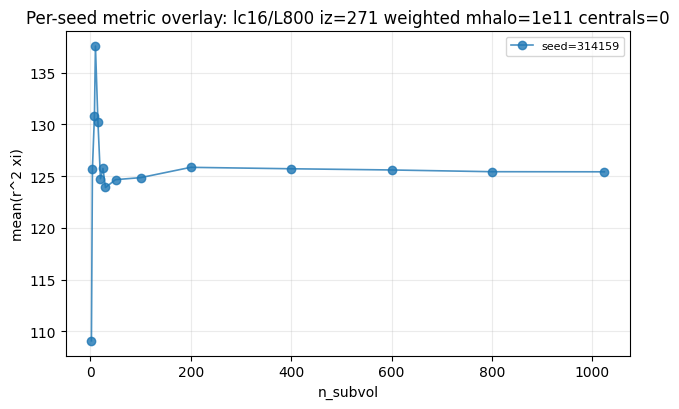

In [6]:
# Random-seeded convergence comparison (selection-seed sensitivity)

if 'CONVERGENCE_RAND_DF' not in globals() or CONVERGENCE_RAND_DF.empty:
    print('No random-seeded convergence data loaded yet. Run the loader cell first.')
else:
    rnd = CONVERGENCE_RAND_DF.copy()
    rnd = rnd.dropna(subset=['r', 'xi', 'n_subvol'])

    if rnd.empty:
        print('Random dataframe has no plottable rows after dropping NaNs.')
    else:
        # Normalize mode labels from multiple job generations.
        mode_map = {
            'standard': 'normal',
            'normal': 'normal',
            'halo': 'weighted',
            'weighted': 'weighted',
        }
        rnd['mode_norm'] = rnd['mode'].map(mode_map).fillna(rnd['mode'])

        rmin, rmax = 3.0, 20.0
        rnd = rnd[(rnd['r'] >= rmin) & (rnd['r'] <= rmax)]

        if rnd.empty:
            print(f'No random rows in r-window [{rmin}, {rmax}] Mpc/h.')
        else:
            rnd['metric'] = (rnd['r'] ** 2) * rnd['xi']

            # Fill missing seeds to keep grouping robust when legacy outputs omit selection_seed.
            rnd['selection_seed'] = rnd['selection_seed'].fillna(-1).astype(int)

            agg = (
                rnd.groupby(
                    ['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only', 'selection_seed', 'n_subvol'],
                    as_index=False,
                )
                .agg(metric=('metric', 'mean'), n_points=('metric', 'size'))
            )

            # Seed-spread metric at fixed n_subvol: std(metric)/|mean(metric)|.
            seed_stats = (
                agg.groupby(['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only', 'n_subvol'], as_index=False)
                   .agg(
                       n_seed=('selection_seed', 'nunique'),
                       metric_mean=('metric', 'mean'),
                       metric_std=('metric', 'std'),
                   )
            )
            seed_stats['seed_cv'] = seed_stats['metric_std'] / seed_stats['metric_mean'].abs().replace(0, np.nan)
            seed_stats.loc[seed_stats['n_seed'] <= 1, 'seed_cv'] = 0.0

            print(
                'Seed spread note: CV=0.0 where only one seed is currently available '
                '(interim state while additional seeded runs finish).'
            )

            display(
                seed_stats.sort_values(['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only', 'n_subvol'])
                         .head(30)
            )

            # Define expected lc16 L800 seeded matrix (what was submitted).
            expected_rows = []
            for iz in [271, 207, 155]:
                for mode in ['normal', 'weighted']:
                    for mhalo_tag in ['1e9', '1e11', '1e13']:
                        for centrals_only in [0, 1]:
                            expected_rows.append(('lc16', 'L800', iz, mode, mhalo_tag, centrals_only))

            expected_idx = pd.MultiIndex.from_tuples(
                expected_rows,
                names=['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only'],
            )
            present_idx = pd.MultiIndex.from_frame(
                seed_stats[['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only']].drop_duplicates()
            )
            missing_idx = expected_idx.difference(present_idx)

            print(f'Random seeded completion: {len(present_idx)}/{len(expected_idx)} expected combo groups')
            if len(missing_idx):
                print('Missing random combo groups (first 30):')
                display(pd.DataFrame(list(missing_idx[:30]), columns=expected_idx.names))
            else:
                print('Random seeded combo groups are complete for expected lc16/L800 matrix.')

            # Focused visualization on weighted mode first (science-priority).
            focus = seed_stats[
                (seed_stats['model'] == 'lc16')
                & (seed_stats['sim'] == 'L800')
                & (seed_stats['mode_norm'] == 'weighted')
                & (seed_stats['iz'].isin([271, 207, 155]))
                & (seed_stats['mhalo_tag'].isin(['1e9', '1e11', '1e13']))
                & (seed_stats['centrals_only'].isin([0, 1]))
            ].copy()

            if focus.empty:
                print('No focused lc16/L800 weighted random-seed rows yet; plotting all available groups.')
                focus = seed_stats.copy()

            groups = (
                focus[['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only']]
                .drop_duplicates()
                .sort_values(['model', 'sim', 'iz', 'mode_norm', 'mhalo_tag', 'centrals_only'])
            )

            if groups.empty:
                print('No random groups available to plot yet.')
            else:
                groups = groups.head(12)  # keep grid readable
                ncols = 3
                nrows = int(np.ceil(len(groups) / ncols))
                fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows), squeeze=False)
                axes = axes.ravel()

                for i, row in enumerate(groups.itertuples(index=False)):
                    ax = axes[i]
                    model, sim, iz, mode_norm, mhalo_tag, centrals_only = row
                    sdf = focus[
                        (focus['model'] == model)
                        & (focus['sim'] == sim)
                        & (focus['iz'] == iz)
                        & (focus['mode_norm'] == mode_norm)
                        & (focus['mhalo_tag'] == mhalo_tag)
                        & (focus['centrals_only'] == centrals_only)
                    ].sort_values('n_subvol')

                    if sdf.empty:
                        ax.set_visible(False)
                        continue

                    ax.plot(sdf['n_subvol'], sdf['seed_cv'], marker='o', lw=1.8)
                    ax.grid(alpha=0.25)
                    ax.set_title(
                        f'{model}/{sim} iz={iz} {mode_norm}\nmhalo={mhalo_tag}, centrals={int(centrals_only)}',
                        fontsize=10,
                    )
                    ax.set_xlabel('n_subvol')
                    ax.set_ylabel('seed spread (CV)')
                    ymax = np.nanpercentile(sdf['seed_cv'].dropna(), 95) if sdf['seed_cv'].notna().any() else 0.0
                    ax.set_ylim(0, max(0.05, 1.2 * ymax))

                for j in range(len(groups), len(axes)):
                    axes[j].set_visible(False)

                plt.tight_layout()
                plt.show()

            # Optional direct per-seed overlay for one representative combo.
            rep = agg[
                (agg['model'] == 'lc16')
                & (agg['sim'] == 'L800')
                & (agg['mode_norm'] == 'weighted')
                & (agg['iz'] == 271)
                & (agg['mhalo_tag'] == '1e11')
                & (agg['centrals_only'] == 0)
            ].copy()

            if not rep.empty:
                plt.figure(figsize=(6.5, 4.2))
                for seed, sdf in rep.groupby('selection_seed'):
                    sdf = sdf.sort_values('n_subvol')
                    label = f'seed={seed}' if seed >= 0 else 'seed=unknown'
                    plt.plot(sdf['n_subvol'], sdf['metric'], marker='o', lw=1.2, alpha=0.8, label=label)
                plt.grid(alpha=0.25)
                plt.title('Per-seed metric overlay: lc16/L800 iz=271 weighted mhalo=1e11 centrals=0')
                plt.xlabel('n_subvol')
                plt.ylabel('mean(r^2 xi)')
                plt.legend(ncol=2, fontsize=8)
                plt.tight_layout()
                plt.show()
            else:
                print('Representative per-seed overlay combo not available yet.')